# Class Imbalance Ablation: DistilBERT + LoRA

Two ablations:
1. **Balanced (undersample)** — balance the 90k train subset by undersampling safe → ~36k. Tests whether balance helps, but confounded by data loss.
2. **Balanced (same size)** — draw 90k from a balanced pool (full dataset, safe undersampled to 50/50). Isolates the effect of class distribution with training size held constant.

In [ ]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("../../../..").resolve()
DATA_DIR = Path("data")
MODEL_TYPE = "transformer_lora"
DATA_PATH = ROOT / "data" / "train_dataset_clean.csv"
GLOBAL_MODEL_DIR = ROOT / "data" / "models" / MODEL_TYPE
TRAIN_SIZE = 90000  # matches global model's train split

ABLATION_DIR = DATA_DIR / "balanced"
ABLATION_SAME_DIR = DATA_DIR / "balanced_same_size"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)
ABLATION_SAME_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

assert GLOBAL_MODEL_DIR.exists() and (GLOBAL_MODEL_DIR / "data_splits.pkl").exists(), (
    f"Global model not found at {GLOBAL_MODEL_DIR}. "
    f"Train it first:\n  python -m model.train --model {MODEL_TYPE} "
    f"--data data/train_dataset_clean.csv --output {GLOBAL_MODEL_DIR} --train-subset 100000"
)

## 1. Baseline (global model)

In [2]:
if not (GLOBAL_MODEL_DIR / "evaluation_results.json").exists():
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {GLOBAL_MODEL_DIR}

with open(GLOBAL_MODEL_DIR / "evaluation_results.json") as f:
    results_baseline = json.load(f)

print(f"Baseline threshold: {results_baseline['best_threshold']:.2f}")
for m, v in results_baseline['quality_tuned'].items():
    print(f"  {m:15s}: {v:.4f}")

Baseline threshold: 0.49
  precision      : 0.8649
  recall         : 0.7320
  f1_score       : 0.7929
  pr_auc         : 0.8853


## 2. Train & Evaluate (balanced)

In [3]:
if not (ABLATION_DIR / "evaluation_results.json").exists():
    with open(GLOBAL_MODEL_DIR / "data_splits.pkl", "rb") as f:
        splits = pickle.load(f)

    X_train, y_train = splits['X_train'], splits['y_train']
    toxic_idx = np.where(y_train == 1)[0]
    safe_idx = np.where(y_train == 0)[0]
    rng = np.random.RandomState(SEED)
    safe_sampled = rng.choice(safe_idx, size=len(toxic_idx), replace=False)
    bal_idx = np.concatenate([safe_sampled, toxic_idx])
    rng.shuffle(bal_idx)

    balanced_splits = {
        'X_train': X_train[bal_idx], 'y_train': y_train[bal_idx],
        'X_val': splits['X_val'], 'y_val': splits['y_val'],
        'X_test': splits['X_test'], 'y_test': splits['y_test'],
    }
    splits_path = ABLATION_DIR / "data_splits.pkl"
    with open(splits_path, "wb") as f:
        pickle.dump(balanced_splits, f)
    print(f"Balanced train: {len(bal_idx)} samples ({balanced_splits['y_train'].mean():.0%} toxic)")

    !cd {ROOT} && python3 -m model.train --model {MODEL_TYPE} --data-splits {splits_path.resolve()} --output {ABLATION_DIR.resolve()}
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {ABLATION_DIR.resolve()}
else:
    print(f"Results already exist in {ABLATION_DIR}, skipping.")

Balanced train: 36108 samples (50% toxic)
Loading data splits from /Users/narly/Code/Study/S26/GENAI/GenAI-Safety-Fliter/model/experiments/transformer_lora/class_imbalance/data/balanced/data_splits.pkl...
Train: 36108, Val: 10000, Test: 92061
Train toxicity rate: 50.00%
Device: mps
Loading weights: 100%|█| 100/100 [00:00<00:00, 4883.46it/s, Materializing param=
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arc

## 3. Load Results

In [4]:
with open(ABLATION_DIR / "evaluation_results.json") as f:
    results_ablation = json.load(f)

print("Baseline results loaded:", list(results_baseline.keys()))
print("Ablation results loaded:", list(results_ablation.keys()))

Baseline results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']
Ablation results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']


## 4. Comparison

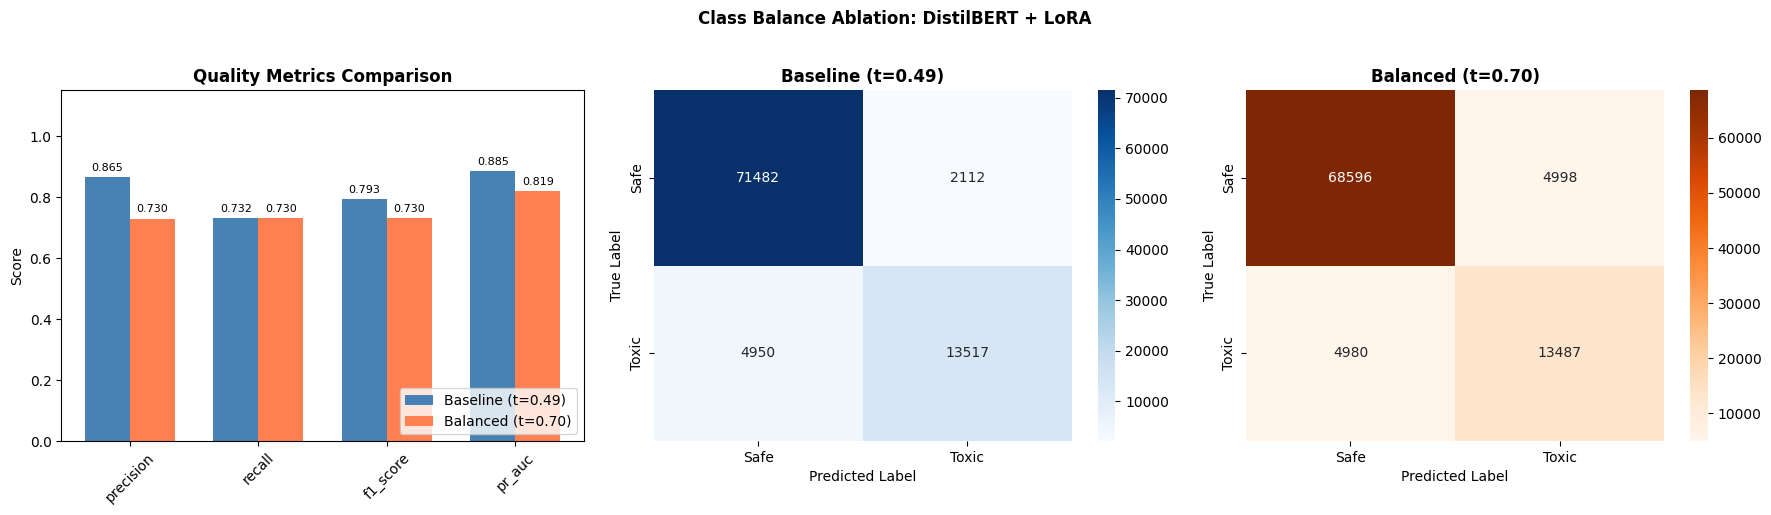


CLASS BALANCE ABLATION SUMMARY (tuned thresholds)
Metric              Baseline     Balanced      Delta
--------------------------------------------------
precision             0.8649       0.7296    -0.1352
recall                0.7320       0.7303    -0.0016
f1_score              0.7929       0.7300    -0.0629
pr_auc                0.8853       0.8186    -0.0667
--------------------------------------------------
Threshold               0.49         0.70


In [5]:
metrics_names = ['precision', 'recall', 'f1_score', 'pr_auc']
base_vals = [results_baseline['quality_tuned'][m] for m in metrics_names]
abl_vals = [results_ablation['quality_tuned'][m] for m in metrics_names]
t_base = results_baseline['best_threshold']
t_abl = results_ablation['best_threshold']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(metrics_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, base_vals, width,
                     label=f'Baseline (t={t_base:.2f})', color='steelblue')
bars2 = axes[0].bar(x + width/2, abl_vals, width,
                     label=f'Balanced (t={t_abl:.2f})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Quality Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=45)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.15)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                 ha='center', fontsize=8)

cm_base = np.array(results_baseline['confusion_matrix_tuned'])
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[1].set_title(f'Baseline (t={t_base:.2f})', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

cm_abl = np.array(results_ablation['confusion_matrix_tuned'])
sns.heatmap(cm_abl, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[2].set_title(f'Balanced (t={t_abl:.2f})', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.suptitle('Class Balance Ablation: DistilBERT + LoRA', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CLASS BALANCE ABLATION SUMMARY (tuned thresholds)")
print("=" * 70)
print(f"{'Metric':<15} {'Baseline':>12} {'Balanced':>12} {'Delta':>10}")
print("-" * 50)
for m in metrics_names:
    bv = results_baseline['quality_tuned'][m]
    av = results_ablation['quality_tuned'][m]
    delta = av - bv
    print(f"{m:<15} {bv:>12.4f} {av:>12.4f} {delta:>+10.4f}")
print("-" * 50)
print(f"{'Threshold':<15} {t_base:>12.2f} {t_abl:>12.2f}")

## 5. Ablation 2: Balanced (same size)

Draw 90k training samples from a balanced pool (full dataset with safe undersampled to 50/50), keeping the same val/test sets. This isolates the effect of class distribution from training size.

In [ ]:
if not (ABLATION_SAME_DIR / "evaluation_results.json").exists():
    with open(GLOBAL_MODEL_DIR / "data_splits.pkl", "rb") as f:
        splits = pickle.load(f)

    # Load full dataset, exclude val/test samples by using the full train pool
    # The global model used --train-subset 100000 from the 80% train split.
    # We need the full 80% train split to draw a balanced 90k from it.
    from sklearn.model_selection import train_test_split

    df = pd.read_csv(DATA_PATH)
    X_all = df['text'].values
    y_all = df['y'].values

    # Reproduce the same 80/20 split to get the full train pool
    X_train_full, _, y_train_full, _ = train_test_split(
        X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
    )

    # Balance the full train pool (undersample safe to match toxic)
    toxic_idx = np.where(y_train_full == 1)[0]
    safe_idx = np.where(y_train_full == 0)[0]
    rng = np.random.RandomState(SEED)
    safe_sampled = rng.choice(safe_idx, size=len(toxic_idx), replace=False)
    bal_pool_idx = np.concatenate([safe_sampled, toxic_idx])
    rng.shuffle(bal_pool_idx)

    X_bal_pool = X_train_full[bal_pool_idx]
    y_bal_pool = y_train_full[bal_pool_idx]
    print(f"Balanced pool: {len(X_bal_pool)} samples ({y_bal_pool.mean():.0%} toxic)")

    # Subsample to match global model's train size
    sample_idx = rng.choice(len(X_bal_pool), size=TRAIN_SIZE, replace=False)
    X_train_bal = X_bal_pool[sample_idx]
    y_train_bal = y_bal_pool[sample_idx]
    print(f"Sampled train: {len(X_train_bal)} samples ({y_train_bal.mean():.0%} toxic)")

    balanced_splits = {
        'X_train': X_train_bal, 'y_train': y_train_bal,
        'X_val': splits['X_val'], 'y_val': splits['y_val'],
        'X_test': splits['X_test'], 'y_test': splits['y_test'],
    }
    splits_path = ABLATION_SAME_DIR / "data_splits.pkl"
    with open(splits_path, "wb") as f:
        pickle.dump(balanced_splits, f)

    !cd {ROOT} && python3 -m model.train --model {MODEL_TYPE} --data-splits {splits_path.resolve()} --output {ABLATION_SAME_DIR.resolve()}
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {ABLATION_SAME_DIR.resolve()}
else:
    print(f"Results already exist in {ABLATION_SAME_DIR}, skipping.")

## 6. Three-way Comparison

In [ ]:
with open(ABLATION_SAME_DIR / "evaluation_results.json") as f:
    results_same_size = json.load(f)

# Three-way comparison
configs = {
    'Baseline\n(90k, 20% toxic)': results_baseline,
    'Balanced\n(36k, 50% toxic)': results_ablation,
    'Balanced same-size\n(90k, 50% toxic)': results_same_size,
}

metrics_names = ['precision', 'recall', 'f1_score', 'pr_auc']

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1. Grouped bar chart
x = np.arange(len(metrics_names))
width = 0.25
colors = ['steelblue', 'coral', 'mediumseagreen']
for i, (label, res) in enumerate(configs.items()):
    vals = [res['quality_tuned'][m] for m in metrics_names]
    t = res['best_threshold']
    bars = axes[0].bar(x + (i - 1) * width, vals, width,
                       label=f'{label} (t={t:.2f})', color=colors[i])
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                     ha='center', fontsize=7)

axes[0].set_ylabel('Score')
axes[0].set_title('Quality Metrics', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=45)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_ylim(0, 1.15)

# 2-4. Confusion matrices
for i, (label, res) in enumerate(configs.items()):
    cm = np.array(res['confusion_matrix_tuned'])
    cmap = ['Blues', 'Oranges', 'Greens'][i]
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i + 1],
                xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
    axes[i + 1].set_title(label, fontweight='bold', fontsize=10)
    axes[i + 1].set_ylabel('True Label')
    axes[i + 1].set_xlabel('Predicted Label')

plt.suptitle('Class Balance Ablation: DistilBERT + LoRA', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("CLASS BALANCE ABLATION SUMMARY (tuned thresholds)")
print("=" * 80)
print(f"{'Metric':<15} {'Baseline':>14} {'Bal (36k)':>14} {'Bal (90k)':>14}")
print("-" * 60)
for m in metrics_names:
    bv = results_baseline['quality_tuned'][m]
    av = results_ablation['quality_tuned'][m]
    sv = results_same_size['quality_tuned'][m]
    print(f"{m:<15} {bv:>14.4f} {av:>14.4f} {sv:>14.4f}")
print("-" * 60)
print(f"{'Threshold':<15} {results_baseline['best_threshold']:>14.2f} "
      f"{results_ablation['best_threshold']:>14.2f} "
      f"{results_same_size['best_threshold']:>14.2f}")
print(f"{'Train size':<15} {'90,000':>14} {'36,108':>14} {'90,000':>14}")
print(f"{'Toxic ratio':<15} {'20%':>14} {'50%':>14} {'50%':>14}")

## Interpretation

**Experimental setup.** Three LoRA models compared, all using DistilBERT + LoRA (`lr=3e-4`, `epochs=2`, `batch_size=128`, `r=8`, `lora_alpha=16`, early stopping `patience=1`), evaluated on the same held-out test set (~92k, ~20% toxic):

| Config | Train size | Toxic ratio | Data source |
|---|---|---|---|
| **Baseline** | 90k | 20% | 100k subset, standard split |
| **Balanced (undersample)** | ~36k | 50% | Baseline's train, safe undersampled |
| **Balanced (same size)** | 90k | 50% | Full train pool, safe undersampled, then 90k drawn |

**Key questions:**
1. Does balancing help LoRA? (Baseline vs Balanced 36k)
2. Is the degradation from balancing caused by data loss or distribution change? (Balanced 36k vs Balanced 90k)

**Expected patterns:**
- If balanced 36k < baseline but balanced 90k > baseline: data loss was the bottleneck, balanced distribution helps when size is held constant.
- If balanced 90k ≈ balanced 36k ≈ baseline: LoRA is insensitive to class distribution at this scale.
- If balanced 90k < baseline: balanced distribution actively hurts, regardless of size.

**Confound for balanced same-size:** the 90k balanced training samples are drawn from different data than baseline (full pool vs 100k subset), so some difference may reflect data composition rather than purely class balance.